# Compare two suite2p runs to localize a cell-count regression

Two runs of the same data, same config, different suite2p versions:

- **OLD (target)** — `suite2p_mbo` 2.0.1, lbm_suite2p_python 2.5.7, cellpose 4.1.1
- **NEW (broken)** — upstream `suite2p` 1.0.0.x, lbm_suite2p_python 3.0.x, cellpose 4.1.1

Same ops (anatomical_only=4, diameter=4, spatial_hp_cp=0, no registration), same input movie, but different final cell counts.

This notebook walks the pipeline output and pinpoints where the two runs diverge:
1. Compare scalar params written to ops — sanity-check they really did run with the same settings.
2. Verify the raw binaries are identical — if they aren't, the regression is in `mbo_utilities`'s writer.
3. Compare summary images (`meanImg`, `max_proj`) — what cellpose actually saw.
4. Compare ROI populations — what cellpose returned and what filters did to it.
5. Spatially match ROIs across runs and find which ones are unique to OLD.

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# edit these to point at your two run plane dirs
OLD_DIR = Path(r"D:\demo\results_mbo2-7-7\zplane01_tp00001-01574")
NEW_DIR = Path(r"D:\demo\results_mbo3-0-1\zplane01_tp00001-01574")

OLD_LABEL, NEW_LABEL = "OLD (mbo)", "NEW (1.0.0.x)"

for d in (OLD_DIR, NEW_DIR):
    assert d.exists(), f"missing: {d}"
    print(d, "->", sorted(p.name for p in d.glob("*.npy")))

D:\demo\results_mbo2-7-7\zplane01_tp00001-01574 -> ['F.npy', 'Fneu.npy', 'dff.npy', 'iscell.npy', 'ops.npy', 'roi_stats.npy', 'spks.npy', 'stat.npy', 'zstats.npy']
D:\demo\results_mbo3-0-1\zplane01_tp00001-01574 -> ['F.npy', 'Fneu.npy', 'db.npy', 'detect_outputs.npy', 'dff.npy', 'iscell.npy', 'ops.npy', 'reg_outputs.npy', 'roi_stats.npy', 'settings.npy', 'spks.npy', 'stat.npy', 'zcorr.npy', 'zstats.npy']


In [3]:
def load_run(plane_dir: Path) -> dict:
    out = {"plane_dir": plane_dir}
    out["ops"] = np.load(plane_dir / "ops.npy", allow_pickle=True).item()
    out["stat"] = np.load(plane_dir / "stat.npy", allow_pickle=True)
    iscell_path = plane_dir / "iscell.npy"
    out["iscell"] = np.load(iscell_path, allow_pickle=True) if iscell_path.exists() else None
    return out

old = load_run(OLD_DIR)
new = load_run(NEW_DIR)

print(f"{OLD_LABEL}: {len(old['stat'])} ROIs")
print(f"{NEW_LABEL}: {len(new['stat'])} ROIs")

if old["iscell"] is not None and new["iscell"] is not None:
    o_acc = int(old["iscell"][:, 0].sum()) if old["iscell"].ndim == 2 else int(old["iscell"].sum())
    n_acc = int(new["iscell"][:, 0].sum()) if new["iscell"].ndim == 2 else int(new["iscell"].sum())
    print(f"{OLD_LABEL}: {o_acc} accepted")
    print(f"{NEW_LABEL}: {n_acc} accepted")

OLD (mbo): 258 ROIs
NEW (1.0.0.x): 229 ROIs
OLD (mbo): 230 accepted
NEW (1.0.0.x): 210 accepted


## 1. Scalar params side-by-side

Confirm the two runs actually ran with the same settings. Anything that differs in this table is a candidate cause for the regression.

In [4]:
PARAM_KEYS = [
    # core
    "fs", "tau", "nframes", "Ly", "Lx",
    # binning / detection algo
    "nbinned", "nbins", "high_pass", "highpass_time",
    "anatomical_only", "sparse_mode", "algorithm",
    # cellpose knobs
    "diameter", "cellprob_threshold", "flow_threshold",
    "spatial_hp_cp", "highpass_spatial",
    "pretrained_model", "cellpose_model",
    # roi_stats filtering
    "npix_norm_min", "npix_norm_max", "max_overlap", "soma_crop",
    # cropping
    "yrange", "xrange",
]

def fmt(v):
    if isinstance(v, np.ndarray):
        return f"ndarray{tuple(v.shape)} {v.tolist() if v.size <= 4 else '...'}"
    return repr(v)

rows = []
for k in PARAM_KEYS:
    o = old["ops"].get(k, "<absent>")
    n = new["ops"].get(k, "<absent>")
    same = "==" if (type(o) == type(n) and (o == n if not isinstance(o, np.ndarray) else np.array_equal(o, n))) else "!="
    rows.append((k, fmt(o), same, fmt(n)))

w_k = max(len(r[0]) for r in rows)
w_o = max(len(r[1]) for r in rows)
for k, o, eq, n in rows:
    print(f"{k:<{w_k}}  {o:<{w_o}}  {eq}  {n}")

fs                  14.0                   ==  14.0
tau                 1.2999999523162842     ==  1.2999999523162842
nframes             1574                   ==  1574
Ly                  550                    ==  550
Lx                  448                    ==  448
nbinned             5000                   ==  5000
nbins               '<absent>'             ==  '<absent>'
high_pass           100                    ==  100
highpass_time       '<absent>'             ==  '<absent>'
anatomical_only     4                      !=  3
sparse_mode         True                   !=  False
algorithm           '<absent>'             !=  'cellpose'
diameter            np.float32(12.021314)  !=  ndarray(2,) [4.0, 4.0]
cellprob_threshold  -6.0                   ==  -6.0
flow_threshold      0.0                    ==  0.0
spatial_hp_cp       0.0                    ==  0.0
highpass_spatial    '<absent>'             ==  '<absent>'
pretrained_model    'cpsam'                ==  'cpsam'
cellpose_mod

## 1.5. Verify the input binaries are identical

Each plane dir has its own `data_raw.bin` (and a `data.bin` that's a copy of it when registration is skipped). If those raw binaries differ between OLD and NEW, all downstream comparisons are meaningless — the divergence is in the writer (`mbo_utilities`), not in suite2p. Quick byte-level + numerical check.

In [5]:
import hashlib

def hash_file(p, chunk=1 << 20):
    h = hashlib.md5()
    with open(p, "rb") as f:
        for blk in iter(lambda: f.read(chunk), b""):
            h.update(blk)
    return h.hexdigest(), p.stat().st_size

for name in ("data_raw.bin", "data.bin"):
    o = OLD_DIR / name; n = NEW_DIR / name
    if not (o.exists() and n.exists()):
        print(f"{name}: missing in {'old' if not o.exists() else 'new'} - skip"); continue
    ho, so = hash_file(o); hn, sn = hash_file(n)
    print(f"{name}")
    print(f"  OLD  size={so:>12,d}  md5={ho}")
    print(f"  NEW  size={sn:>12,d}  md5={hn}")
    print(f"  identical: {ho == hn and so == sn}")

data_raw.bin: missing in old - skip
data.bin
  OLD  size= 775,667,200  md5=de323b410c2b66f1a41ec8038ad41a81
  NEW  size= 775,667,200  md5=002834f1b6ee5091b89c4a767ece66e5
  identical: False


In [6]:
# numerical comparison of the raw frames (read first 50 frames + check whole-file mean/max)
Ly = int(old["ops"]["Ly"]); Lx = int(old["ops"]["Lx"])
n_frames = int(old["ops"]["nframes"])
FRAMES_TO_CHECK = min(50, n_frames)

def memmap_raw(path):
    return np.memmap(path, dtype=np.int16, mode="r", shape=(n_frames, Ly, Lx))

for name in ("data_raw.bin", "data.bin"):
    o = OLD_DIR / name; n = NEW_DIR / name
    if not (o.exists() and n.exists()):
        continue
    mo = memmap_raw(o); mn = memmap_raw(n)
    head_o = np.array(mo[:FRAMES_TO_CHECK]); head_n = np.array(mn[:FRAMES_TO_CHECK])
    diff_head = head_o.astype(np.int32) - head_n.astype(np.int32)
    full_mean_o = float(np.mean(mo[::20]))   # subsample every 20th frame for speed
    full_mean_n = float(np.mean(mn[::20]))
    full_max_o  = int(mo[::20].max())
    full_max_n  = int(mn[::20].max())
    print(f"{name}")
    print(f"  first {FRAMES_TO_CHECK} frames per-pixel diff: max_abs={np.max(np.abs(diff_head))}  mean_abs={np.mean(np.abs(diff_head)):.4f}  bytewise_identical={(head_o == head_n).all()}")
    print(f"  whole-file (every 20th frame) mean: OLD={full_mean_o:.3f}  NEW={full_mean_n:.3f}")
    print(f"  whole-file (every 20th frame) max:  OLD={full_max_o}  NEW={full_max_n}")
    del mo, mn

data.bin
  first 50 frames per-pixel diff: max_abs=4229  mean_abs=174.1763  bytewise_identical=False
  whole-file (every 20th frame) mean: OLD=1178.466  NEW=1178.464
  whole-file (every 20th frame) max:  OLD=16991  NEW=17330


In [7]:
def array_diff(a, b, name):
    if a is None or b is None:
        print(f"  {name}: missing in one run")
        return
    print(f"  {name}")
    print(f"    shapes: {a.shape}  vs  {b.shape}")
    if a.shape != b.shape:
        print("    cannot diff (shape mismatch)")
        return
    a = a.astype(np.float64); b = b.astype(np.float64)
    d = a - b
    print(f"    range A: [{a.min():.4g}, {a.max():.4g}]  mean={a.mean():.4g}")
    print(f"    range B: [{b.min():.4g}, {b.max():.4g}]  mean={b.mean():.4g}")
    print(f"    diff: max_abs={np.max(np.abs(d)):.4g}  mean_abs={np.mean(np.abs(d)):.4g}")
    print(f"    allclose(rtol=1e-4)={np.allclose(a, b, rtol=1e-4)}")
    a_norm = a / (np.abs(a).max() + 1e-9)
    b_norm = b / (np.abs(b).max() + 1e-9)
    print(f"    diff after peak-normalize: max_abs={np.max(np.abs(a_norm - b_norm)):.4g}")

for key in ("meanImg", "max_proj", "meanImgE"):
    array_diff(old["ops"].get(key), new["ops"].get(key), key)

  meanImg
    shapes: (550, 448)  vs  (550, 448)
    range A: [-25.63, 7612]  mean=1182
    range B: [-43.82, 7551]  mean=1182
    diff: max_abs=1223  mean_abs=11.1
    allclose(rtol=1e-4)=False
    diff after peak-normalize: max_abs=0.1678
  max_proj
    shapes: (550, 448)  vs  (550, 448)
    range A: [75.87, 9689]  mean=491
    range B: [66.71, 9536]  mean=464.9
    diff: max_abs=1872  mean_abs=49.34
    allclose(rtol=1e-4)=False
    diff after peak-normalize: max_abs=0.2067
  meanImgE
    shapes: (550, 448)  vs  (550, 448)
    range A: [0, 1]  mean=0.5263
    range B: [0, 1]  mean=0.3924
    diff: max_abs=1  mean_abs=0.1431
    allclose(rtol=1e-4)=False
    diff after peak-normalize: max_abs=1


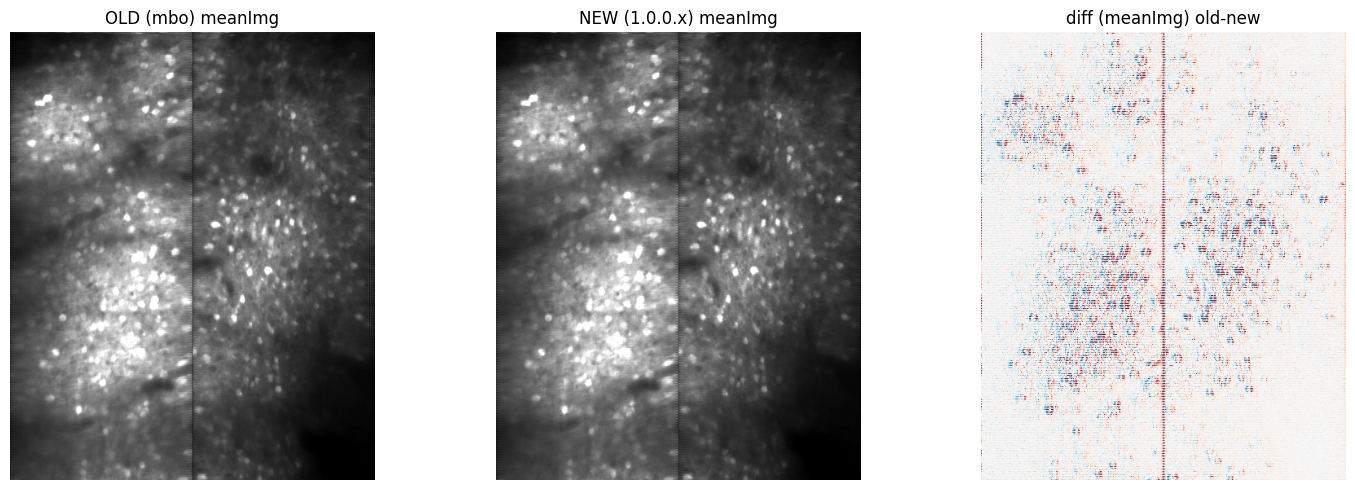

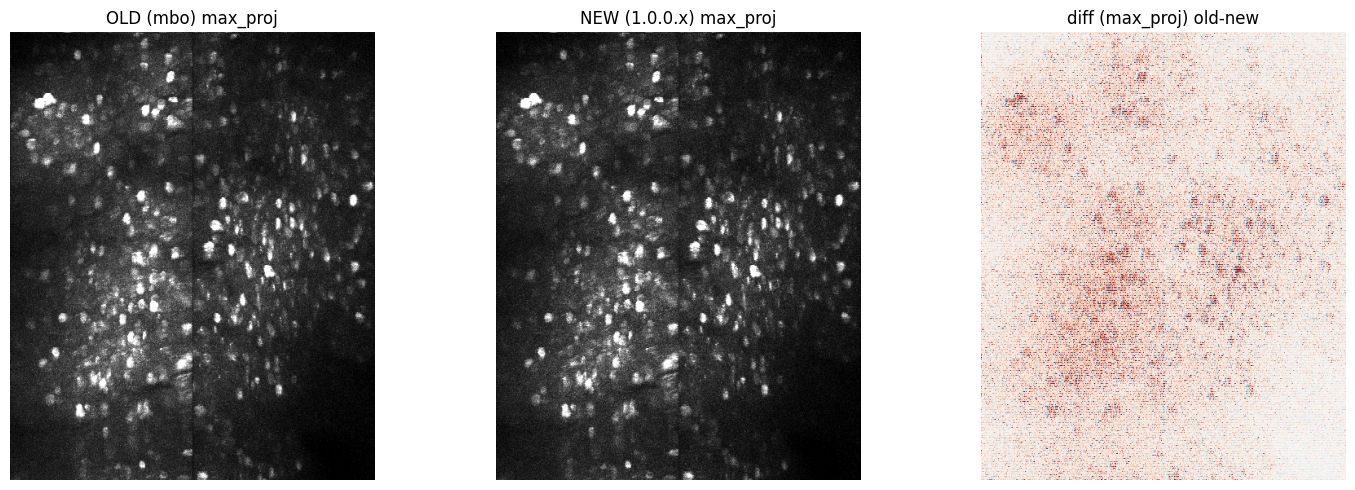

In [8]:
def show_pair(key, vmin_pct=1, vmax_pct=99):
    a = old["ops"].get(key); b = new["ops"].get(key)
    if a is None or b is None or a.shape != b.shape:
        print(f"skipping {key} (missing or shape mismatch)")
        return
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    vmin = np.percentile(np.concatenate([a.ravel(), b.ravel()]), vmin_pct)
    vmax = np.percentile(np.concatenate([a.ravel(), b.ravel()]), vmax_pct)
    axs[0].imshow(a, vmin=vmin, vmax=vmax, cmap="gray"); axs[0].set_title(f"{OLD_LABEL} {key}")
    axs[1].imshow(b, vmin=vmin, vmax=vmax, cmap="gray"); axs[1].set_title(f"{NEW_LABEL} {key}")
    d = a.astype(float) - b.astype(float)
    lim = np.percentile(np.abs(d), 99) or 1
    axs[2].imshow(d, vmin=-lim, vmax=lim, cmap="RdBu_r"); axs[2].set_title(f"diff ({key}) old-new")
    for ax in axs: ax.set_axis_off()
    plt.tight_layout(); plt.show()

show_pair("meanImg")
show_pair("max_proj")

## 3. ROI population stats

If summary images match but ROI counts differ, the divergence is in cellpose itself or in `roi_stats` filtering. Distribution of `radius`, `npix`, `npix_norm`, `compact` tells us which ROIs are missing.

In [9]:
def stat_array(stats, key):
    return np.array([s.get(key, np.nan) for s in stats], dtype=float)

STAT_KEYS = ["npix", "npix_soma", "npix_norm", "radius", "compact", "aspect_ratio"]
for k in STAT_KEYS:
    o = stat_array(old["stat"], k); n = stat_array(new["stat"], k)
    o_v = o[~np.isnan(o)]; n_v = n[~np.isnan(n)]
    if len(o_v) == 0 and len(n_v) == 0:
        continue
    print(f"{k:<14}  N(old)={len(o_v):>4d}  median(old)={np.median(o_v):.3g}  range=[{o_v.min():.3g}, {o_v.max():.3g}]")
    print(f"{'':>14}  N(new)={len(n_v):>4d}  median(new)={np.median(n_v):.3g}  range=[{n_v.min():.3g}, {n_v.max():.3g}]")

npix            N(old)= 258  median(old)=114  range=[25, 344]
                N(new)= 229  median(new)=121  range=[28, 342]
npix_soma       N(old)= 258  median(old)=104  range=[24, 320]
                N(new)= 229  median(new)=115  range=[23, 323]
npix_norm       N(old)= 258  median(old)=0.925  range=[0.213, 2.83]
                N(new)= 229  median(new)=1  range=[0.2, 2.81]
radius          N(old)= 258  median(old)=6  range=[2.91, 10.6]
                N(new)= 229  median(new)=6.48  range=[2.71, 10.3]
compact         N(old)= 258  median(old)=1.01  range=[1, 1.23]
                N(new)= 229  median(new)=1.01  range=[1, 1.12]
aspect_ratio    N(old)= 258  median(old)=1.1  range=[0.992, 1.51]
                N(new)= 229  median(new)=1.1  range=[1, 1.39]


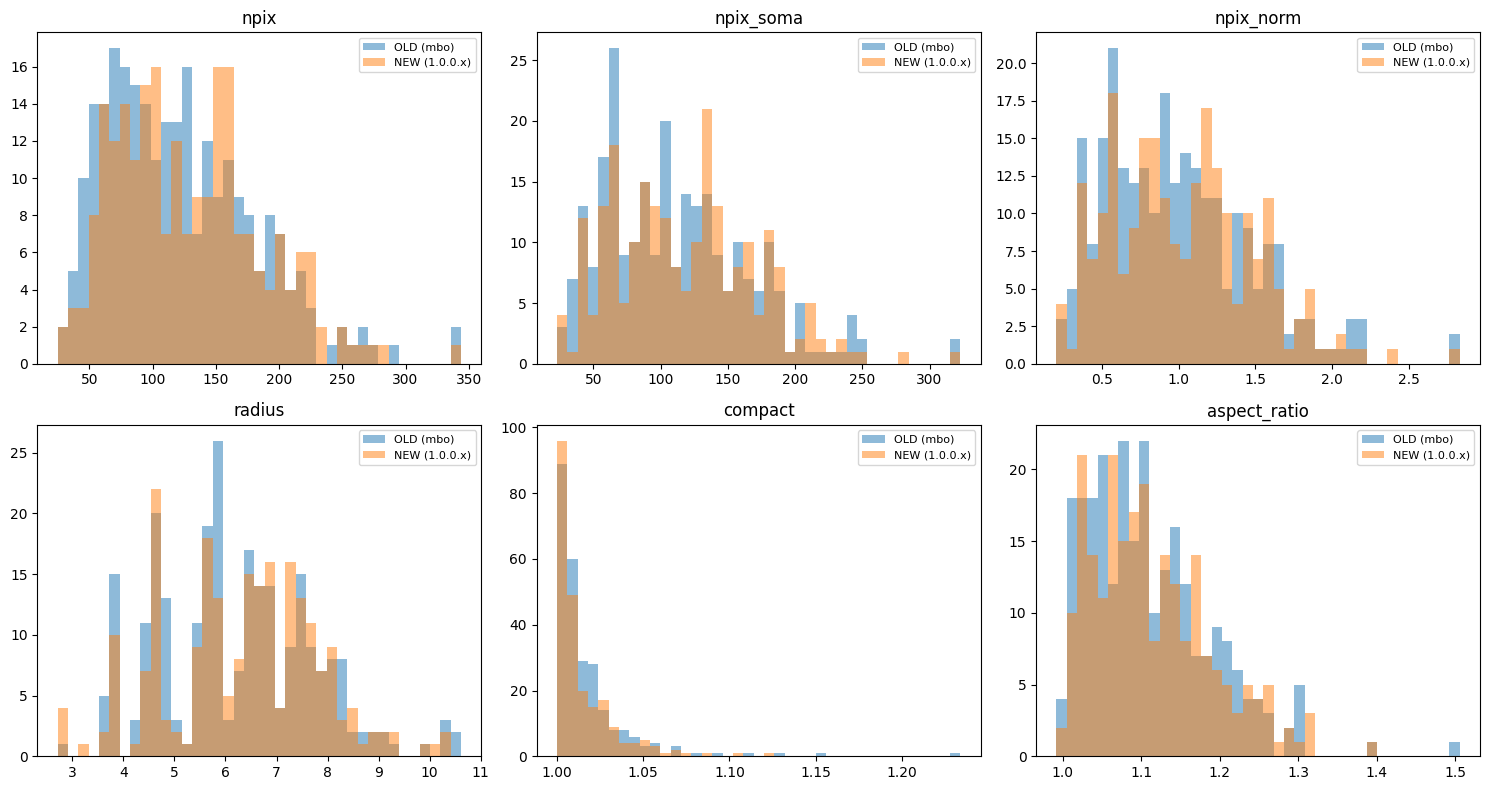

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
for ax, k in zip(axs.ravel(), STAT_KEYS):
    o = stat_array(old["stat"], k); n = stat_array(new["stat"], k)
    o = o[~np.isnan(o)]; n = n[~np.isnan(n)]
    if len(o) == 0 and len(n) == 0:
        ax.set_title(f"{k} (no data)"); continue
    bins = np.linspace(min(o.min() if len(o) else 0, n.min() if len(n) else 0),
                       max(o.max() if len(o) else 1, n.max() if len(n) else 1), 40)
    ax.hist(o, bins=bins, alpha=0.5, label=OLD_LABEL, color="C0")
    ax.hist(n, bins=bins, alpha=0.5, label=NEW_LABEL, color="C1")
    ax.set_title(k); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Spatial ROI matching - which ROIs are missing in NEW?

Match each OLD ROI to its nearest NEW ROI (by centroid). ROIs in OLD with no NEW match within ~1 cell diameter are the ones that got dropped. Plotting them on `max_proj` shows whether they're real cells or borderline cases.

In [11]:
def centers(stats):
    return np.array([s["med"] for s in stats], dtype=float)

old_c = centers(old["stat"]); new_c = centers(new["stat"])
diam = float(np.mean(np.atleast_1d(new["ops"].get("diameter", [12., 12.]))))
match_radius = max(diam, 6.0)  # px

from scipy.spatial.distance import cdist
D = cdist(old_c, new_c)
nearest_dist = D.min(axis=1)
old_unmatched = nearest_dist > match_radius

DT = D.T
nearest_dist_n = DT.min(axis=1)
new_unmatched = nearest_dist_n > match_radius

print(f"matching radius: {match_radius:.2f} px")
print(f"OLD ROIs total: {len(old_c)}")
print(f"  matched in NEW: {(~old_unmatched).sum()}")
print(f"  ONLY in OLD (dropped): {old_unmatched.sum()}")
print(f"NEW ROIs total: {len(new_c)}")
print(f"  ONLY in NEW (gained): {new_unmatched.sum()}")

matching radius: 6.00 px
OLD ROIs total: 258
  matched in NEW: 220
  ONLY in OLD (dropped): 38
NEW ROIs total: 229
  ONLY in NEW (gained): 10


In [ ]:
max_proj = old["ops"].get("max_proj", new["ops"].get("max_proj"))
fig, axs = plt.subplots(1, 2, figsize=(14, 7))
vmin, vmax = np.percentile(max_proj, [1, 99])
for ax in axs:
    ax.imshow(max_proj, vmin=vmin, vmax=vmax, cmap="gray")
    ax.set_axis_off()

axs[0].scatter(old_c[~old_unmatched, 1], old_c[~old_unmatched, 0], s=10, c="lime", label="matched")
axs[0].scatter(old_c[old_unmatched, 1], old_c[old_unmatched, 0], s=20, c="red", marker="x", label="only in OLD")
axs[0].set_title(f"{OLD_LABEL}: green=matched, red=dropped"); axs[0].legend(loc="upper right", fontsize=8)

axs[1].scatter(new_c[~new_unmatched, 1], new_c[~new_unmatched, 0], s=10, c="lime", label="matched")
axs[1].scatter(new_c[new_unmatched, 1], new_c[new_unmatched, 0], s=20, c="yellow", marker="+", label="only in NEW")
axs[1].set_title(f"{NEW_LABEL}: green=matched, yellow=new"); axs[1].legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

## 5. Profile the dropped ROIs

Are the OLD-only ROIs systematically smaller / dimmer / more elongated? If they cluster in a region of stat-space, that points at a specific filter or threshold.

In [ ]:
if old_unmatched.sum() > 0:
    dropped = old["stat"][old_unmatched]
    matched_old = old["stat"][~old_unmatched]
    fig, axs = plt.subplots(2, 3, figsize=(15, 8))
    for ax, k in zip(axs.ravel(), STAT_KEYS):
        d = stat_array(dropped, k); d = d[~np.isnan(d)]
        m = stat_array(matched_old, k); m = m[~np.isnan(m)]
        if len(d) == 0 and len(m) == 0:
            ax.set_title(f"{k} (no data)"); continue
        bins = np.linspace(min(d.min() if len(d) else 0, m.min() if len(m) else 0),
                           max(d.max() if len(d) else 1, m.max() if len(m) else 1), 30)
        ax.hist(m, bins=bins, alpha=0.5, label=f"OLD matched (n={len(m)})", color="C2")
        ax.hist(d, bins=bins, alpha=0.5, label=f"OLD-only dropped (n={len(d)})", color="C3")
        ax.set_title(k); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("no dropped ROIs to profile")

## 6. Where to look next, based on what you find

| Observation | Implication |
|---|---|
| `data_raw.bin` md5 differs | `mbo_utilities` writer changed - test by re-running pipeline against OLD's data_raw.bin |
| Raw binaries match but `max_proj` differs | suite2p's `bin_movie` / `temporal_high_pass_filter` is the divergence |
| `max_proj` arrays match (`allclose=True`) | Divergence is inside cellpose or `roi_stats` - re-run with `torch.backends.cudnn.deterministic=True` |
| Dropped ROIs cluster at low `npix_norm` or low `radius` | A size filter is firing |
| Dropped ROIs cluster at high `compact` (elongated) | Shape filter / aspect_ratio cutoff |
| Dropped ROIs scattered, near image edges | yrange / xrange cropping difference |